In [1]:
import pandas as pd
from datasets import load_dataset

dataset = load_dataset(
    "takala/financial_phrasebank",
    "sentences_75agree",
    trust_remote_code=True,
)

dataset

/Users/anushreegoyal/PycharmProjects/FinancialNewsML/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 3453
    })
})

In [2]:
# Inspect the dataset structure
dataset

# Look at some examples
dataset["train"][0:5]






{'sentence': ['According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .',
  'With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .',
  "For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year earlier , while it moved to a zero pre-tax profit from a pre-tax loss of EUR7m .",
  'In the third quarter of 2010 , net sales increased by 5.2 % to EUR 205.5 mn , and operating profit by 34.9 % to EUR 23.5 mn .',
  'Operating profit rose to EUR 13.1 mn from EUR 8.7 mn in the corresponding period in 2007 representing 7.7 % of net sales .'],
 'label': [1, 2, 2, 2, 2]}

In [3]:
# Convert to pandas
df = dataset["train"].to_pandas()

df.head()

,sentence,label
0,"According to Gran , the company has no plans t...",1
1,With the new production plant the company woul...,2
2,"For the last quarter of 2010 , Componenta 's n...",2
3,"In the third quarter of 2010 , net sales incre...",2
4,Operating profit rose to EUR 13.1 mn from EUR ...,2


# Exploratory Data Analysis

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3453 entries, 0 to 3452
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   sentence  3453 non-null   str  
 1   label     3453 non-null   int64
dtypes: int64(1), str(1)
memory usage: 475.2 KB


## Label distribution and data quality

In [ ]:
label_names = {0: "negative", 1: "neutral", 2: "positive"}
df["sentiment"] = df["label"].map(label_names)

#to make labels readable


df.head()

,sentence,label,sentiment
0,"According to Gran , the company has no plans t...",1,neutral
1,With the new production plant the company woul...,2,positive
2,"For the last quarter of 2010 , Componenta 's n...",2,positive
3,"In the third quarter of 2010 , net sales incre...",2,positive
4,Operating profit rose to EUR 13.1 mn from EUR ...,2,positive


Map numeric targets to sentiment names for analysis and visualization.

In [6]:
print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum())
print("\nDuplicate sentences:", df["sentence"].duplicated().sum())
print("\nClass counts:")
print(df["sentiment"].value_counts())

Dataset shape: (3453, 3)

Missing values:
sentence     0
label        0
sentiment    0
dtype: int64

Duplicate sentences: 5

Class counts:
sentiment
neutral     2146
positive     887
negative     420
Name: count, dtype: int64


The class distribution is imbalanced, with neutral observations forming the majority. Model evaluation should therefore include class-level precision, recall, and F1 scores.

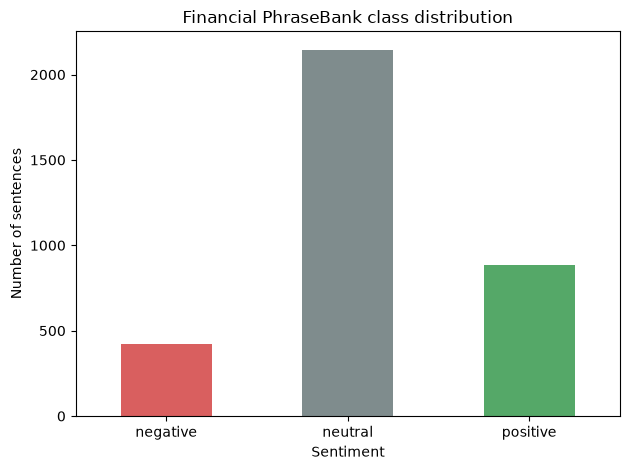

In [7]:
import matplotlib.pyplot as plt

class_order = ["negative", "neutral", "positive"]
df["sentiment"].value_counts().reindex(class_order).plot(
    kind="bar",
    color=["#d95f5f", "#7f8c8d", "#55a868"],
)
plt.title("Financial PhraseBank class distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of sentences")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Duplicate handling

In [8]:
duplicate_rows = df[df["sentence"].duplicated(keep=False)]
duplicate_rows.sort_values("sentence")

,sentence,label,sentiment
1544,Ahlstrom 's share is quoted on the NASDAQ OMX ...,1,neutral
1545,Ahlstrom 's share is quoted on the NASDAQ OMX ...,1,neutral
1681,SSH Communications Security Corporation is hea...,1,neutral
1682,SSH Communications Security Corporation is hea...,1,neutral
2195,The company serves customers in various indust...,1,neutral
2196,The company serves customers in various indust...,1,neutral
773,The issuer is solely responsible for the conte...,1,neutral
774,The issuer is solely responsible for the conte...,1,neutral
958,The report profiles 614 companies including ma...,1,neutral
959,The report profiles 614 companies including ma...,1,neutral


Review duplicated sentences and their labels before removal.

In [9]:
df = df.drop_duplicates(subset="sentence").reset_index(drop=True)

print("Rows after removing duplicates:", len(df))
print("Duplicates remaining:", df["sentence"].duplicated().sum())

Rows after removing duplicates: 3448
Duplicates remaining: 0


Five duplicate sentences had consistent labels and were removed before splitting to prevent train-test leakage. The cleaned dataset contains 3,448 unique sentences.

## Stratified train-test split

In [10]:
from sklearn.model_selection import train_test_split

X = df["sentence"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

In [11]:
split_summary = pd.DataFrame(
    {
        "rows": [len(X_train), len(X_test)],
        "negative_share": [
            (y_train == 0).mean(),
            (y_test == 0).mean(),
        ],
        "neutral_share": [
            (y_train == 1).mean(),
            (y_test == 1).mean(),
        ],
        "positive_share": [
            (y_train == 2).mean(),
            (y_test == 2).mean(),
        ],
    },
    index=["train", "test"],
).round(3)

split_summary

,rows,negative_share,neutral_share,positive_share
train,2758,0.122,0.621,0.257
test,690,0.122,0.620,0.258


The 80/20 stratified split preserves class proportions across the training and held-out test sets. The test set remains untouched during feature and model development.